#Import Library

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

%matplotlib inline

# Data Source

In [106]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [107]:
df = pd.read_csv(data)
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [108]:
n = len(df) # Check numnber of rows in dataset.
print(f'total: {n} rows')

total: 10000 rows


In [109]:
data1 = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
    "fuel_efficiency_mpg"
] # Select engine_displacement ,horsepower,vehicle_weight,model_year and fuel_efficiency_mpg

In [110]:
df[data1].describe() # Explore general statistics from data1

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


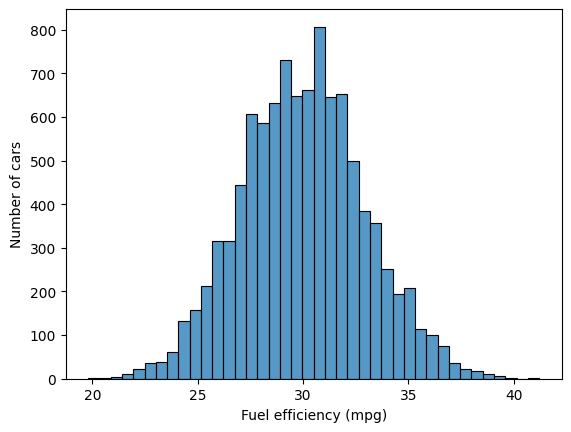

,fuel_efficiency_mpg
count,10000.000000
mean,29.997700
std,2.930245
min,19.800000
25%,28.000000
50%,30.000000
75%,31.900000
max,41.200000


In [111]:
# Check the distribution of the fuel_efficiency_mpg.
sns.histplot(df["fuel_efficiency_mpg"], bins=40)
plt.xlabel("Fuel efficiency (mpg)")
plt.ylabel("Number of cars")
plt.show()

# Compare the center and range
df["fuel_efficiency_mpg"].describe()

#Question 1 There's one column with missing values. What is it?

In [150]:
df[data1].isnull().sum() # check the missing value columns in data set from 4 features.

,0
engine_displacement,0
horsepower,877
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


#Question 2 What's the median (50% percentile) for variable 'horsepower'?


In [149]:
horse_power_median = df['horsepower'].median() # check horse_power_median from data1
print(f'median horsepower: {horse_power_median}')

median horsepower: 254.0


# Setting up the validation framework
Training set, validation set and test set

In [173]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
]

In [174]:
n = len(df) # Check the total number of rows in the dataset.
n_val = int(n * 0.2) # Set 20% of the rows for the validation set.
n_test = int(n * 0.2) # Set 20% of the rows for the test set.
n_train = n - n_val - n_test  # Set the remaining rows for the training set.

np.random.seed(42) # Use seed 42 to get the same random order every time.
idx = np.arange(n) # Create row positions from 0 to n - 1.
np.random.shuffle(idx) # Shuffle the row positions in idx.

df_train = df.iloc[idx[:n_train]]  # Select the first 6000 shuffled positions for training.
df_val = df.iloc[idx[n_train:n_train + n_val]]  # Select the next 2000 shuffled positions for validation.
df_test = df.iloc[idx[n_train + n_val:]] # Select the last 2000 shuffled positions for testing.

print("Train:", len(df_train)) # Show the number of rows in the training set.
print("Validation:", len(df_val)) # Show the number of rows in the validation set.
print("Test:", len(df_test)) # Show the number of rows in the test set.

Train: 6000
Validation: 2000
Test: 2000


In [176]:
def train_linear_regression(X, y):  # Create a function to train linear regression.
    ones = np.ones(X.shape[0])  # Create one value of 1 for each row in X.
    X = np.column_stack([ones, X])  # Add the ones as the first column for the bias.

    XTX = X.T.dot(X)  # Multiply the transpose of X by X.
    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)  # Calculate all model weights.

    return w_full[0], w_full[1:]  # Return the bias and the feature weights separately.


def rmse(y, y_pred):  # Create a function to measure prediction error.
    return np.sqrt(np.mean((y_pred - y) ** 2))  # Calculate the root mean squared error.

# Question 3 Which option gives better RMSE?

## RMSE with 0

In [177]:
y_train = df_train["fuel_efficiency_mpg"].values  # Select the target values from the training set.
y_val = df_val["fuel_efficiency_mpg"].values  # Select the target values from the validation set.

X_train_zero = df_train[features].fillna(0).values  # Select training features and fill missing values with 0.
X_val_zero = df_val[features].fillna(0).values  # Select validation features and fill missing values with 0.

w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)  # Train the model using the training set.
y_pred_zero = w0_zero + X_val_zero.dot(w_zero)  # Predict the target values for the validation set.
score_zero = rmse(y_val, y_pred_zero)  # Compare the predictions with the actual validation values.

print("With 0:", round(score_zero, 3))  # Show the RMSE rounded to three decimal places.

With 0: 2.205


## RMSE with Mean

In [178]:
horsepower_mean = df_train["horsepower"].mean()  # Calculate the horsepower mean using the training set only.

X_train_mean = df_train[features].fillna(horsepower_mean).values  # Fill missing training features with the training mean.
X_val_mean = df_val[features].fillna(horsepower_mean).values  # Fill missing validation features with the same training mean.

w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)  # Train a new model using the mean-filled data.
y_pred_mean = w0_mean + X_val_mean.dot(w_mean)  # Predict the target values for the validation set.
score_mean = rmse(y_val, y_pred_mean)  # Compare the predictions with the actual validation values.

print("With mean:", round(score_mean, 3))  # Show the RMSE rounded to three decimal places.

With mean: 2.202


In [179]:
print("RMSE with 0:   ", round(score_zero, 3))  # Show the RMSE when missing values are filled with 0.
print("RMSE with mean:", round(score_mean, 3))  # Show the RMSE when missing values are filled with the training mean.

RMSE with 0:    2.205
RMSE with mean: 2.202


# Question 4 Which r gives the best RMSE?

In [180]:
def train_linear_regression_reg(X, y, r):  # Create a function to train linear regression with regularization.
    ones = np.ones(X.shape[0])  # Create one value of 1 for each row in X.
    X = np.column_stack([ones, X])  # Add the ones as the first column for the bias.

    XTX = X.T.dot(X)  # Multiply the transpose of X by X.
    XTX = XTX + r * np.eye(XTX.shape[0])  # Add regularization to the diagonal of XTX.

    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)  # Calculate all model weights.
    return w_full[0], w_full[1:]  # Return the bias and the feature weights separately.

In [181]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
] # Select the four columns used as model inputs.

X_train = df_train[features].fillna(0).values  # Select training features and fill missing values with 0.
X_val = df_val[features].fillna(0).values  # Select validation features and fill missing values with 0.

y_train = df_train["fuel_efficiency_mpg"].values  # Select the actual target values for training.
y_val = df_val["fuel_efficiency_mpg"].values  # Select the actual target values for validation.

In [182]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]  # Set the regularization values to test.
scores = {}  # Create a dictionary to store the RMSE for each r.

for r in r_values:  # Try each regularization value.
    w0, w = train_linear_regression_reg(X_train, y_train, r)  # Train the model using the current r.

    y_pred = w0 + X_val.dot(w)  # Predict the target values for the validation set.
    score = rmse(y_val, y_pred)  # Calculate the validation RMSE.
    scores[r] = round(score, 4)  # Store the RMSE rounded to four decimal places.

    print(f"r={r:<6} RMSE={scores[r]:.4f}")  # Show r and its RMSE.

best_r = min(r_values, key=lambda r: (scores[r], r))  # Select the lowest RMSE; choose the smaller r if tied.
print("Best r:", best_r)  # Show the best regularization value.

r=0      RMSE=2.2053
r=0.01   RMSE=2.2058
r=0.1    RMSE=2.2241
r=1      RMSE=2.3492
r=5      RMSE=2.4094
r=10     RMSE=2.4195
r=100    RMSE=2.4292
Best r: 0


# Question 5 What's the value of std?

In [183]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
] # Select the four columns used as model inputs.

target = "fuel_efficiency_mpg" # Set the value the model will predict.

df_q5 = df[features + [target]].copy() # columns needed for Question 5.

n = len(df_q5)  # Count the total number of rows.
n_val = int(n * 0.2)  # Set 20% of the rows for validation.
n_test = int(n * 0.2)  # Set 20% of the rows for testing.
n_train = n - n_val - n_test  # Set the remaining rows for training.

rmse_scores = []  # Create a list to store the RMSE from each seed.

for seed in range(10):  # Try seeds from 0 to 9.
    np.random.seed(seed)  # Set the current seed for shuffling.
    idx = np.arange(n)  # Create row positions from 0 to n - 1.
    np.random.shuffle(idx)  # Shuffle the row positions.

    df_train_seed = df_q5.iloc[idx[:n_train]]  # Select the first 60% for training.
    df_val_seed = df_q5.iloc[idx[n_train:n_train + n_val]]  # Select the next 20% for validation.
    df_test_seed = df_q5.iloc[idx[n_train + n_val:]]  # Select the last 20% for testing.

    X_train = df_train_seed[features].fillna(0).values  # Fill missing training features with 0.
    X_val = df_val_seed[features].fillna(0).values  # Fill missing validation features with 0.
    y_train = df_train_seed[target].values  # Select the training target values.
    y_val = df_val_seed[target].values  # Select the validation target values.

    w0, w = train_linear_regression(X_train, y_train)  # Train without regularization.
    y_pred = w0 + X_val.dot(w)  # Predict the validation target values.
    score = rmse(y_val, y_pred)  # Calculate the validation RMSE.

    rmse_scores.append(score)  # Add this RMSE to the list.
    print(f"seed={seed} RMSE={score:.4f}")  # Show the RMSE for this seed.

std = np.std(rmse_scores)  # Calculate the standard deviation of all ten RMSE scores.
print("Standard deviation:", round(std, 3))  # Show the result rounded to three decimal places.

seed=0 RMSE=2.2392
seed=1 RMSE=2.2021
seed=2 RMSE=2.1634
seed=3 RMSE=2.2044
seed=4 RMSE=2.2019
seed=5 RMSE=2.2458
seed=6 RMSE=2.2697
seed=7 RMSE=2.1908
seed=8 RMSE=2.2166
seed=9 RMSE=2.2070
Standard deviation: 0.029


# Question 6 What's the RMSE on the test dataset?

In [184]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
]  # Select the four columns used as model inputs.
target = "fuel_efficiency_mpg"  # Set the value the model will predict.

df_q6 = df[features + [target]].copy()  # columns needed for Question 6.

n = len(df_q6)  # Count the total number of rows.
n_val = int(n * 0.2)  # Set 20% of the rows for validation.
n_test = int(n * 0.2)  # Set 20% of the rows for testing.
n_train = n - n_val - n_test  # Set the remaining rows for training.

np.random.seed(9)  # Use seed 9 to get the split required by the question.
idx = np.arange(n)  # Create row positions from 0 to n - 1.
np.random.shuffle(idx)  # Shuffle the row positions.

df_train = df_q6.iloc[idx[:n_train]]  # Select the first 60% for training.
df_val = df_q6.iloc[idx[n_train:n_train + n_val]]  # Select the next 20% for validation.
df_test = df_q6.iloc[idx[n_train + n_val:]]  # Select the last 20% for testing.

df_full_train = pd.concat([df_train, df_val])  # Combine the training and validation sets.

X_full_train = df_full_train[features].fillna(0).values  # Fill missing features in the combined set with 0.
y_full_train = df_full_train[target].values  # Select the target values from the combined set.

X_test = df_test[features].fillna(0).values  # Fill missing test features with 0.
y_test = df_test[target].values  # Select the actual target values from the test set.

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)  # Train with r = 0.001.
y_pred = w0 + X_test.dot(w)  # Predict the target values for the test set.
score = rmse(y_test, y_pred)  # Calculate the RMSE on the test set.

print("Test RMSE:", round(score, 3))  # Show the test RMSE rounded to three decimal places.

Test RMSE: 2.236
